In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library

<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/iportfolio/images/logos/kuleuven.png/@@images/image-800-e89431243530c6a800aa1186b9f6891b.png" width = auto, heigh = 200px align=left>
</div>


KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">Team 27></span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red"> Fosteris Emmanouil, Paschalidis Marios, Greiner Luc, Reyes Salazar Jose, Digenis Stefanos</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [3]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    'datasets/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    'datasets/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('datasets/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('datasets/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [6]:
# The training set contains an identifier, name, image information and class label
train_X.head(1)


NameError: name 'train_x' is not defined

In [ ]:
# The test set only contains an identifier and corresponding image information.

test.head(1)

In [ ]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [ ]:
class HAARPreprocessor():
    """Preprocessing pipeline built around HAAR feature based cascade classifiers. """
    
    def __init__(self, path, face_size):
        self.face_size = face_size
        file_path = os.path.join(path, "haarcascade_frontalface_default.xml")
        if not os.path.exists(file_path): 
            if not os.path.exists(path):
                os.mkdir(path)
            self.download_model(file_path)
        
        self.classifier = cv2.CascadeClassifier(file_path)
  
    def download_model(self, path):
        url = "https://raw.githubusercontent.com/opencv/opencv/master/data/"\
            "haarcascades/haarcascade_frontalface_default.xml"
        
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())
            
    def detect_faces(self, img):
        """Detect all faces in an image."""
        
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return self.classifier.detectMultiScale(
            img_gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
    def extract_faces(self, img):
        """Returns all faces (cropped) in an image."""
        
        faces = self.detect_faces(img)

        return [img[y:y+h, x:x+w] for (x, y, w, h) in faces]
    
    def preprocess(self, data_row):
        faces = self.extract_faces(data_row['img'])
        
        # if no faces were found, return None
        if len(faces) == 0:
            nan_img = np.empty(self.face_size + (3,))
            nan_img[:] = np.nan
            return nan_img
        
        # only return the first face
        return cv2.resize(faces[0], self.face_size, interpolation = cv2.INTER_AREA)
            
    def __call__(self, data):
        return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)

**Visualise**

Let's plot a few examples.

In [9]:
# parameter to play with 
FACE_SIZE = (100, 100)

def plot_image_sequence(data, n, imgs_per_row=7):
    n_rows = 1 + int(n/(imgs_per_row+1))
    n_cols = min(imgs_per_row, n)

    f,ax = plt.subplots(n_rows,n_cols, figsize=(10*n_cols,10*n_rows))
    for i in range(n):
        if n == 1:
            ax.imshow(data[i])
        elif n_rows > 1:
            ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i])
        else:
            ax[int(i%n)].imshow(data[i])
    plt.show()

    




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..249.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..240.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [23.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..253.0].
Clipping input data to the valid range for imshow with RGB da

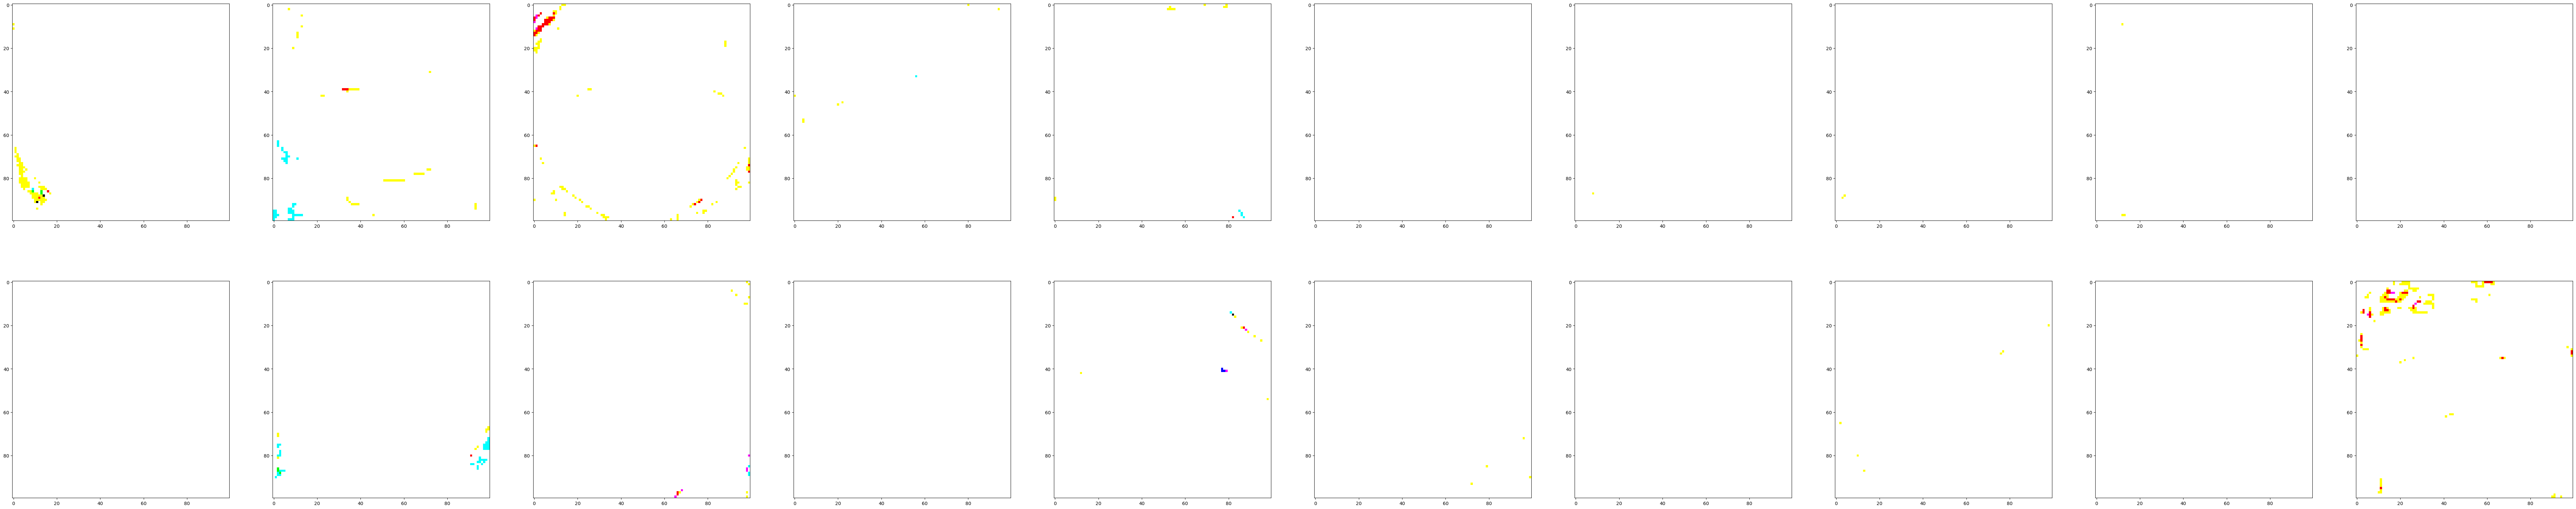

In [12]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

In [11]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.0..254.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0..240.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [13.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.0..176.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB da

KeyboardInterrupt: 

In [ ]:
class_1_indices = np.where(train_y == 1)[0]

# The 7th one (index 6)
original_index = class_1_indices[5]
print(f"Original index: {original_index}")
plt.imshow(train['img'][original_index], cmap='gray')
plt.title(f"Index: {original_index}, Name: {train['name'][original_index]}")
plt.show()

In [ ]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [ ]:
# save preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
    
# np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
# np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
# np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

# load preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
# train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
# train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
# test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations
## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [9]:
class IdentityFeatureExtractor:
    """A simple function that returns the input"""
    
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform
...

In [ ]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    """TODO: this feature extractor is under construction"""
    
    def __init__(**params):
        self.params = params
        
    def transform(self, X):
        raise NotImplmentedError

### 1.1.1. t-SNE Plots
...

### 1.1.2. Discussion
...

## 1.2. Baseline 2: PCA feature extractor
...

Loading the final dataset   

In [5]:
train_X = np.load('/data/leuven/385/vsc38511/pca/final_train_extracted_faces/train_X.npy')
train_y = np.load('/data/leuven/385/vsc38511/pca/final_train_extracted_faces/train_y.npy')
test_X = np.load('/data/leuven/385/vsc38511/pca/final_train_extracted_faces/test_X.npy')

We convert the test and train images to greyscale.

In [1]:
import numpy as np
import torch
from torchvision import transforms
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Load data
train_X = np.load('/data/leuven/385/vsc38511/pca/final_train_extracted_faces/train_X.npy')
train_y = np.load('/data/leuven/385/vsc38511/pca/final_train_extracted_faces/train_y.npy')
test_X = np.load('/data/leuven/385/vsc38511/pca/final_train_extracted_faces/test_X.npy')

# DINOv2 preprocessing
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model = model.to(device)
model.eval()

# Extract train features
with torch.no_grad():
    train_batch = torch.stack([transform(img.astype(np.uint8)) for img in train_X]).to(device)
    train_features = model(train_batch).cpu().numpy()  # (86, 384)

print(f"Train features shape: {train_features.shape}")

# Train classifier
clf = SVC(kernel='rbf', C=1.0)
clf.fit(train_features, train_y)

# Check training accuracy
train_preds = clf.predict(train_features)
print(classification_report(train_y, train_preds))

Using cache found in /data/leuven/385/vsc38511/.cache/torch/hub/facebookresearch_dinov2_main
/data/leuven/385/vsc38511/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/data/leuven/385/vsc38511/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/data/leuven/385/vsc38511/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/data/leuven/385/vsc38511/miniconda3/envs/gaussctrl_v100/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias

Train features shape: (86, 384)
              precision    recall  f1-score   support

           0       1.00      0.50      0.67        24
           1       0.94      1.00      0.97        30
           2       0.76      1.00      0.86        32

    accuracy                           0.86        86
   macro avg       0.90      0.83      0.83        86
weighted avg       0.89      0.86      0.85        86



In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['rbf', 'linear']}
clf = GridSearchCV(SVC(), param_grid, cv=3, scoring='accuracy')
clf.fit(train_features, train_y)
print(f"Best params: {clf.best_params_}")
print(f"Best CV accuracy: {clf.best_score_:.3f}")

Best params: {'C': 10, 'kernel': 'rbf'}
Best CV accuracy: 0.884


In [7]:
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
model = model.to(device)
model.eval()

with torch.no_grad():
    train_batch = torch.stack([transform(img.astype(np.uint8)) for img in train_X]).to(device)
    train_features = model(train_batch).cpu().numpy()  # (86, 768)

print(f"Train features shape: {train_features.shape}")

# Same grid search
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['rbf', 'linear']}
clf = GridSearchCV(SVC(), param_grid, cv=3, scoring='accuracy')
clf.fit(train_features, train_y)
print(f"Best params: {clf.best_params_}")
print(f"Best CV accuracy: {clf.best_score_:.3f}")

NameError: name 'torch' is not defined

In [11]:
from sklearn.metrics import classification_report

clf_best = clf.best_estimator_
train_preds = clf_best.predict(train_features)
print(classification_report(train_y, train_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        32

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



In [12]:
# Extract test features (batch to avoid OOM)
with torch.no_grad():
    test_features = []
    for i in range(0, len(test_X), 64):
        batch = torch.stack([transform(img.astype(np.uint8)) for img in test_X[i:i+64]]).to(device)
        test_features.append(model(batch).cpu())
    test_features = torch.cat(test_features).numpy()  # (1816, 768)

# Predict
test_preds = clf.best_estimator_.predict(test_features)
print(f"Predictions shape: {test_preds.shape}")
print(f"Class distribution: {np.unique(test_preds, return_counts=True)}")

Predictions shape: (1816,)
Class distribution: (array([0, 1, 2]), array([778, 490, 548]))


In [3]:
pip install onnxruntime gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 60.7 MB/s  0:00:006m0:00:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install insightface onnxruntime

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached cython-3.2.4-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (7.5 kB)
  Using cached coloredlogs-15.0.1-py2.py3-none-any.whl.metadata (12 kB)
  Using cached humanfriendly-10.0-py2.py3-none-any.whl.metadata (9.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 44.7 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 118.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 117.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 582.4/582.4 kB 34.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.5 MB/s  0:00:00
Using cached coloredlogs-15.0.1-py2.py3-none-any.whl (46 kB)
Using cached humanfriendly-10.0-py2.py3-none-any.whl (86 kB)
Using cached cython-3.2.4-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_

In [5]:
import numpy as np
from deepface import DeepFace
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Load data
train_X = np.load('/data/leuven/385/vsc38511/pca/final_train_extracted_faces/train_X.npy')
train_y = np.load('/data/leuven/385/vsc38511/pca/final_train_extracted_faces/train_y.npy')

# Extract Facenet512 embeddings
train_features = []
for i, img in enumerate(train_X):
    emb = DeepFace.represent(img.astype(np.uint8), model_name="Facenet512",
                              enforce_detection=False, detector_backend="skip")
    train_features.append(emb[0]["embedding"])
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(train_X)}")

train_features = np.array(train_features)  # (86, 512)
print(f"Train features shape: {train_features.shape}")

# Train classifier with grid search
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['rbf', 'linear']}
clf = GridSearchCV(SVC(), param_grid, cv=3, scoring='accuracy')
clf.fit(train_features, train_y)

print(f"Best params: {clf.best_params_}")
print(f"Best CV accuracy: {clf.best_score_:.3f}")

# Training set report
train_preds = clf.best_estimator_.predict(train_features)
print(classification_report(train_y, train_preds))

ValueError: An exception occurred while loading the pre-trained weights from /user/leuven/385/vsc38511/.deepface/weights/facenet512_weights.h5.This might have happened due to an interruption during the download.You may want to delete it and allow DeepFace to download it again during the next run.If the issue persists, consider downloading the file directly from the source and copying it to the target folder.

In [4]:
# pip install deepface
from deepface import DeepFace
import numpy as np

# Extract 512-d face embeddings
train_features = []
for img in train_X:
    emb = DeepFace.represent(img.astype(np.uint8), model_name="ArcFace", 
                              enforce_detection=False)
    train_features.append(emb[0]["embedding"])
train_features = np.array(train_features)  # (86, 512)

ImportError: cannot import name 'LocallyConnected2D' from 'tensorflow.keras.layers' (/vsc-hard-mounts/leuven-data/385/vsc38511/gaussctrl-fork/.conda/lib/python3.11/site-packages/keras/_tf_keras/keras/layers/__init__.py)

In [14]:
test_y_star = test_preds
import pandas as pd

submission = pd.DataFrame({'class': test_preds})
submission.to_csv('submission.csv', index=True)

Plotting the first 7 images of each class.

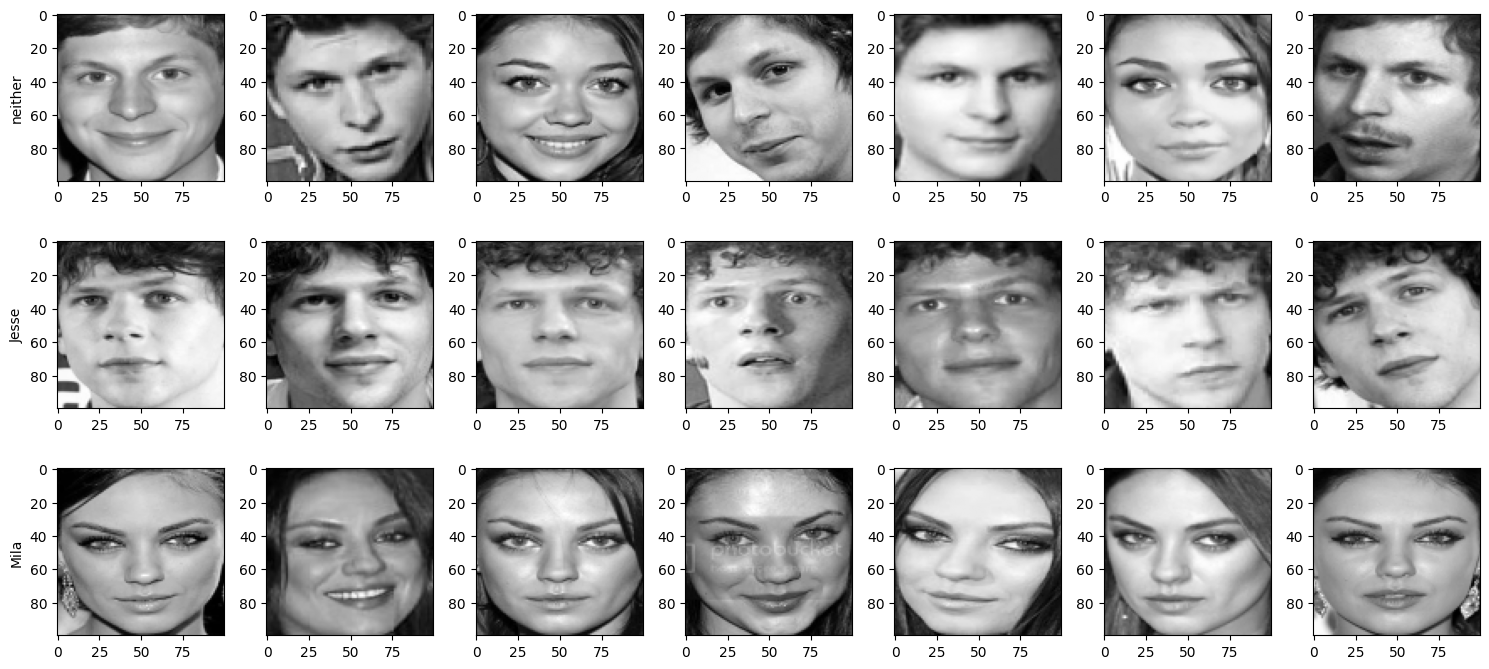

In [6]:
label_names = ['neither', 'Jesse', 'Mila']

fig, axes = plt.subplots(3, 7, figsize=(15, 7))
for row, label in enumerate([0, 1, 2]):
    mask = train_y == label
    images = train_X_gray[mask]
    for col in range(7):
        axes[row, col].imshow(images[col], cmap='gray')
        if col == 0:
            axes[row, col].set_ylabel(label_names[label])
plt.tight_layout()
plt.show()

Our training images are currently in shape (86, 100, 100), meaning each image is a 2D grid of 100x100 pixels. Our images need to be 1D flat vector, so we then flatten each image from a 100x100 grid into a single row of 10000 values. This gives us a final data matrix of shape (86, 10000), where each row represents one image.

In [7]:
#Flatten the Images
train_X_flat = train_X_gray.reshape(train_X_gray.shape[0], -1)
test_X_flat = test_X_gray.reshape(test_X_gray.shape[0], -1)

print(train_X_flat.shape)  
print(train_y.shape) 
print(test_X_flat.shape)

(86, 10000)
(86,)
(1816, 10000)


In standard PCA, we would compute the covariance matrix of our data. However, our data matrix has shape (86, 10000), meaning the covariance matrix would have shape (10000, 10000), which is 100 million values. This is computationally very expensive and in many cases impossible to handle directly. Instead, we use Singular Value Decomposition (SVD), which allows us to extract the same principal components without ever explicitly computing the covariance matrix, making it much more efficient for high-dimensional data like images.

## PCA Feature Extractor

We use the class `PCAFeatureExtractor` to extract eigenface features from the face images.

**`fit(X)`**: Subtracts the mean face from every image so that the data is centered around zero. This is a required step before applying SVD, as PCA assumes the data is mean-centered. It then applies Singular Value Decomposition and stores the S vector (which contains the singular values, related to the eigenvalues of the covariance matrix) and the Vt matrix (whose rows are the principal components, i.e. the eigenfaces).

**`transform(X)`**: Projects images into the reduced PCA space by centering them with the same mean face and multiplying by the first `n_components` eigenfaces. Each image is represented as a compact feature vector of `n_components` values instead of thousands of pixels.

**`inverse_transform(X_projected)`**: Reconstructs images from their PCA representation back to pixel space by multiplying the coefficients by the eigenfaces and adding the mean face back. This is useful for visualizing how much information is retained at different numbers of components.

In [10]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean_face = X.mean(axis=0)
        X_centered = X - self.mean_face
        U, self.S, self.Vt = np.linalg.svd(X_centered, full_matrices=False)

    def transform(self, X):
        return (X - self.mean_face) @ self.Vt[:self.n_components, :].T

    def inverse_transform(self, X_projected):
        return X_projected @ self.Vt[:self.n_components, :] + self.mean_face

### Scree Plot and Choosing the Number of Components

To determine how many principal components to retain, we analyze how much variance each component explains. The singular values from SVD tell us this. Specifically, the squared singular values are proportional to the eigenvalues of the covariance matrix. By dividing each squared singular value by the total sum, we get the percentage of variance explained by each component.

We plot these values in a scree plot and look for the "elbow", the point where the curve flattens and additional components stop contributing meaningful information. We also compute the cumulative variance of the first 20 components to verify that we retain enough of the total variance for classification.

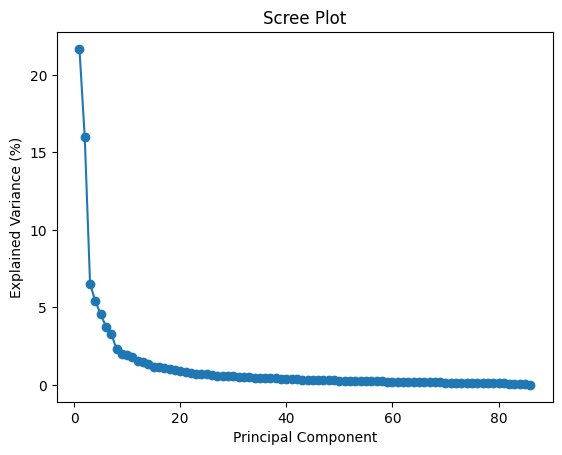

First 20 PCs explain: 79.87%


In [11]:
pca = PCAFeatureExtractor(n_components=20)
pca.fit(train_X_flat)

squared_s = pca.S ** 2
explained_var = squared_s / squared_s.sum() * 100

plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.show()

print(f"First 20 PCs explain: {np.sum(explained_var[:20]):.2f}%")

### Interpretation

The scree plot shows a clear elbow around 5-8 components, after which the individual contributions flatten out significantly. The first component alone explains about 22% of the variance, and the first two together account for nearly 38%. Beyond the first 10 components, each additional component contributes less than 2%.

The first 20 principal components explain 79.87% of the total variance. In the classification section, we will experiment with different values of p to find the optimal number of components for our task.

Note that the total number of non-zero eigenvalues is 85 (one less than our 86 training images), since mean centering removes one degree of freedom from the data.

### 1.2.1. Eigenface Plots

### Eigenface Reconstructions

To visualize how much information is retained at different numbers of principal components, we reconstruct a single face image using an increasing number of eigenfaces (p = 1, 5, 10, 20, 40, 60, 75).

With p=1, the reconstruction is essentially the mean face with a slight adjustment in one direction of variation, the identity of the person is unrecognizable. By p=5, some facial structure begins to emerge. At p=10, the general shape and features become visible, and by p=20, the face is clearly recognizable as a specific individual. Beyond p=40, the added components contribute finer details such as skin texture and hair strands, but the identity is already well captured at p=20.

This supports our choice of retaining 20 principal components: the essential information needed for face recognition is already present, while the additional components mostly capture high-frequency details and noise that are less useful for classification.

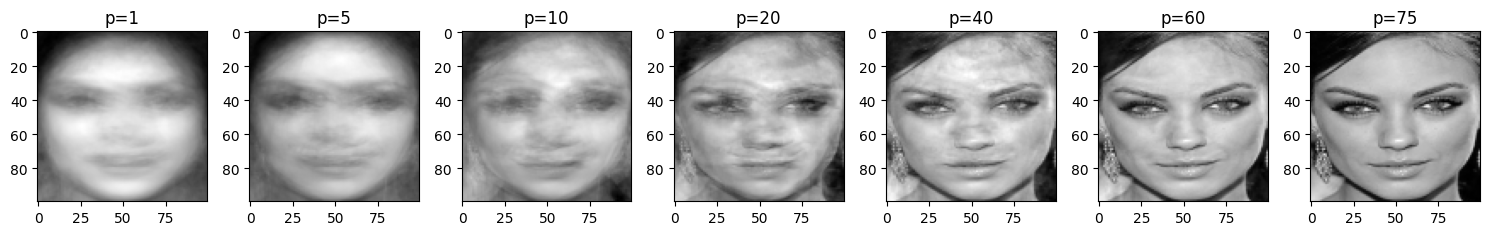

In [12]:
p = [1, 5, 10, 20, 40, 60, 75]
fig, axes = plt.subplots(1, len(p), figsize=(15, 4))
for i, p_val in enumerate(p):
    pca_temp = PCAFeatureExtractor(n_components=p_val)
    pca_temp.fit(train_X_flat)
    coefficients = pca_temp.transform(train_X_flat[0:1])
    reconstruction = pca_temp.inverse_transform(coefficients)
    axes[i].imshow(reconstruction.reshape(100, 100), cmap='gray')
    axes[i].set_title(f'p={p_val}')
plt.tight_layout()
plt.show()

### 1.2.2. Feature Space Plots

### 2D Feature Space Plot

To visualize how well PCA separates the different classes, we project all training images onto the first two principal components and plot them in a scatter plot, colored by class label. This gives us an intuitive view of whether the eigenface features can distinguish between the different identities, even though only two dimensions are used.

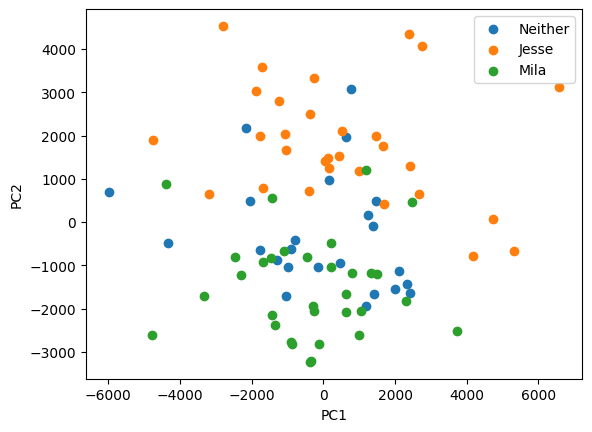

In [13]:
pca_2d = PCAFeatureExtractor(n_components=2)
pca_2d.fit(train_X_flat)
scatter = pca_2d.transform(train_X_flat)

classes = np.unique(train_y)
labels = ['Neither', 'Jesse', 'Mila']
for cls, name in zip(classes, labels):
    mask = train_y == cls
    plt.scatter(scatter[mask, 0], scatter[mask, 1], label=name)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### 1.2.3. Discussion

### Interpretation

Projecting the faces onto the first two principal components reveals some interesting patterns. There is a visible separation between Jesse and Mila, Jesse's images tend to cluster in the upper half of the plot while Mila's images are mostly in the lower half, particularly along PC2. This suggests that even with just two components, PCA captures some meaningful differences.

However, the "Neither" class (Michael Cera and Sarah Hyland) overlaps heavily with both Jesse and Mila. This makes sense, since Michael Cera looks similar to Jesse and Sarah Hyland looks similar to Mila — which is exactly why they were chosen for this dataset. A classifier using only these two features would likely confuse these look-alikes with their counterparts.

Overall, while two components show some discriminative power, they only explain about 38% of the total variance. Using more components for classification should improve separation, especially for distinguishing the look-alikes.

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [ ]:
from sklearn.metrics import accuracy_score

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [19]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

We extract the features of our training and our test data.

In [23]:
pca = PCAFeatureExtractor(n_components=2)
pca.fit(train_X_flat)
train_features = pca.transform(train_X_flat)
test_features = pca.transform(test_X_flat)

In [28]:
#imports for knn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

We implement knn

In [26]:


class FavoriteClassificationModel:
    def __init__(self, n_neighbors=5):
        self.model = KNeighborsClassifier(n_neighbors=n_neighbors)
    
    def fit(self, X, y):
        self.model.fit(X, y)
    
    def predict(self, X):
        return self.model.predict(X)

In [31]:


p_values = [2, 5, 10, 20, 30, 40, 50, 60, 75]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for n_components in p_values:
    pca_eval = PCAFeatureExtractor(n_components=n_components)
    pca_eval.fit(train_X_flat)
    features = pca_eval.transform(train_X_flat)

    fold_accuracies = []
    for train_idx, val_idx in cv.split(features, train_y):
        X_train_cv, X_val_cv = features[train_idx], features[val_idx]
        y_train_cv, y_val_cv = train_y[train_idx], train_y[val_idx]

        clf_cv = FavoriteClassificationModel(n_neighbors=5)
        clf_cv.fit(X_train_cv, y_train_cv)
        y_pred_cv = clf_cv.predict(X_val_cv)
        fold_accuracies.append(accuracy_score(y_val_cv, y_pred_cv))

    mean_accuracy = np.mean(fold_accuracies)
    results.append((n_components, mean_accuracy))
    print(f"p={n_components:2d}, mean validation accuracy = {mean_accuracy:.4f}")

best_p, best_accuracy = max(results, key=lambda x: x[1])
print(f"\nBest PCA dimensionality: p={best_p} with mean validation accuracy {best_accuracy:.4f}")

best_pca = PCAFeatureExtractor(n_components=best_p)
best_pca.fit(train_X_flat)
train_features_best = best_pca.transform(train_X_flat)
test_features_best = best_pca.transform(test_X_flat)

clf = FavoriteClassificationModel(n_neighbors=5)
clf.fit(train_features_best, train_y)
test_predictions = clf.predict(test_features_best)

p= 2, mean validation accuracy = 0.5928
p= 5, mean validation accuracy = 0.6621
p=10, mean validation accuracy = 0.7438
p=20, mean validation accuracy = 0.7431
p=30, mean validation accuracy = 0.7431
p=40, mean validation accuracy = 0.7549
p=50, mean validation accuracy = 0.7425
p=60, mean validation accuracy = 0.7542
p=75, mean validation accuracy = 0.7542

Best PCA dimensionality: p=40 with mean validation accuracy 0.7549


In [38]:
from sklearn.svm import SVC

# Linear SVM on PCA features with 10 components
pca_10 = PCAFeatureExtractor(n_components=30)
pca_10.fit(train_X_flat)
train_features_10 = pca_10.transform(train_X_flat)
test_features_10 = pca_10.transform(test_X_flat)

# split the training set for validation
X_train_svm, X_val_svm, y_train_svm, y_val_svm = train_test_split(
    train_features_10, train_y, test_size=0.2, stratify=train_y, random_state=42
)

svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train_svm, y_train_svm)

train_acc_10 = accuracy_score(y_train_svm, svm_clf.predict(X_train_svm))
val_acc_10 = accuracy_score(y_val_svm, svm_clf.predict(X_val_svm))
print(f"Linear SVM PCA(10) train accuracy: {train_acc_10:.4f}")
print(f"Linear SVM PCA(10) validation accuracy: {val_acc_10:.4f}")

svm_test_predictions = svm_clf.predict(test_features_10)

Linear SVM PCA(10) train accuracy: 1.0000
Linear SVM PCA(10) validation accuracy: 0.7222


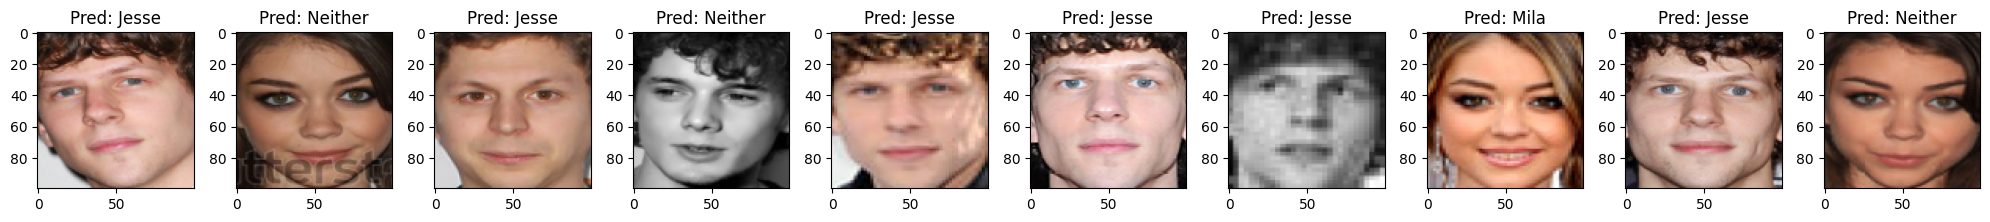

In [ ]:
label_names = ['Neither', 'Jesse', 'Mila']

fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for i in range(10):
    axes[i].imshow(test_X[i].astype(np.uint8))
    axes[i].set_title(f'Pred: {label_names[test_predictions[i]]}')
plt.tight_layout()
plt.show()

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [ ]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [ ]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

In [ ]:
# predict the labels for the test set 
test_y_star = model(test_X)

# 5. Publishing best results

In [ ]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission

In [ ]:
submission.to_csv('submission.csv')

# 6. Discussion
...

In summary we contributed the following: 
* 
